### Dataset Notebook

#### Imports


In [22]:
name = 'noah'

%load_ext autoreload
%autoreload 2

import sys
if name == 'noah': 
    sys.path.append( '/home/lodes/uni/3.semester/project/LLaVA-3D/open3dsg' )
elif name == 'elena': 
    sys.path.append( '/Volumes/scratch/alegretelena/LLaVA-3D/open3dsg' )


import os
import json
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

from const import *
from preprocess_3rscan import Preprocessor
from open_dataset import Open2D3DSGDataset
from get_object_frame import run, read_json

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
mode = "train"
#scan_id = '754e884c-ea24-2175-8b34-cead19d4198d'
scan_id = 'c92fb594-f771-2064-879b-cc598a9dabe5'
export_path = CONF_PATH_R3SCAN_PROCESSED
root = CONF_PATH_R3SCAN_RAW

scene_data, selected_scans = read_json(root, mode)
export_path = os.path.join(export_path, "views")

scans = sorted(list(scene_data.keys()))
print("Storing views in: ", export_path)

for scan in tqdm(scans):
    run(scan, scene_data, export_path=export_path)

Storing views in:  ../data/3RScan/processed/views


100%|██████████| 2/2 [00:00<00:00, 7019.76it/s]


Relationships structure: 

- relationships ==> {'scans': list}
    - list = [{'scan': id, 'objects': {'id': word}, 'relationships': list(..., [obj1_id, obj2_id, relationship_id, next to], ...), 'split': id}]


In [24]:
relationships = json.load(open(os.path.join(CONF_PATH_R3SCAN_RAW, f"relationships_{mode}.json")))["scans"] 
relationship_list = []
for r in relationships:
    if r['scan'] == scan_id:
        #use all splits
        relationship_list.append(r)
        #use only last split
        #relationship_list = [r]

processor = Preprocessor(skip_existing=True, distance="min")
for r in tqdm(relationship_list):
    processor.write_pickle(r)

100%|██████████| 5/5 [00:00<00:00, 8446.04it/s]

c92fb594-f771-2064-879b-cc598a9dabe5-1
skipping already exists
c92fb594-f771-2064-879b-cc598a9dabe5-2
skipping already exists
c92fb594-f771-2064-879b-cc598a9dabe5-3
skipping already exists
c92fb594-f771-2064-879b-cc598a9dabe5-4
skipping already exists
c92fb594-f771-2064-879b-cc598a9dabe5-5
skipping already exists


In [25]:
dataset = Open2D3DSGDataset(
    relationships_R3SCAN=relationship_list,
    relationships_scannet=None,
    openseg=False,
    img_dim=224,
    rel_img_dim=224,
    top_k_frames=5,
    scales=3,
    mini=False,
    load_features=None,
    blip=True,
    llava=False,
    half=False,
    max_objects=9,
    max_rels=72
)

  0%|          | 0/5 [00:00<?, ?it/s]

#### data_dict: 

1. 3D Data (Objects and Geometry):
- objects_pcl: Normalized point cloud data for each object, sampled to a fixed number of points to represent 3D geometry.
- objects_center: A list of centroids (3D coordinates) for each object, representing their spatial positions in the scan.
- tight_bbox: Axis-aligned bounding boxes tightly enclosing each object in the 3D space.
- objects_cat: Categories of the objects, represented as indices corresponding to their semantic labels.

2. Relationships Between Objects:
- triples: A list of subject-object-predicate triples representing the relationships between objects in the scene.
- pairs: Object pairs (subject-object) that are part of a relationship.
- predicate_cat: Categories of relationships (predicates) between objects, represented as indices corresponding to their semantic meaning.
- predicate_dist: Vectors representing the spatial distances between the centroids of object pairs in the scene.
- predicate_min_dist: Minimum distance vectors between points of object pairs in each relationship.

3. Mapping Between 3D and 2D:
- obj2frame: A mapping of objects to the frames (images) where they appear, including details such as visible pixels and 2D bounding boxes.
- rel2frame: A mapping of relationships (object pairs) to the frames where they are visible.
- objects_bbox: 2D bounding boxes of the objects in the frames, specifying their locations in the corresponding images.

4. Visual Data (Images):
- blip_images: Images processed for multimodal tasks, likely using a BLIP model to extract text-image context.
- object_imgs: Images specifically associated with individual objects in the scene.
- relationship_imgs: Images associated with specific relationships between objects.

5. Auxiliary Data:
- scene_id: The unique identifier of the scene, providing contextual information for the scan.
- id2name: A dictionary mapping object IDs to their semantic category names.


In [55]:
data_dict = dataset[1]
print("Split:", data_dict['scan_id'][-1])

Split: 3


In [58]:
data_dict['objects_cat']

array([57., 43.,  2.,  2., 31., 50., 26.,  0.,  0.])

In [59]:
data_dict['objects_id'].shape[0]

9

In [28]:
num_relationships = len(data_dict['triples'])
print(f"Number of relationships (from triples): {num_relationships}")
num_relationships = len(data_dict['predicate_cat'])
print(f"Number of relationships (from predicate_cat): {num_relationships}")
num_relationships = len(data_dict['pairs'])
print(f"Number of relationships (from pairs): {num_relationships}")


Number of relationships (from triples): 44
Number of relationships (from predicate_cat): 72
Number of relationships (from pairs): 72


In [29]:
pair = data_dict['pairs'][4]
predicate_cat = data_dict['predicate_cat']
print(f"Pair for Row 5: {pair}")
print(f"Active columns (indices): {[idx for idx, value in enumerate(predicate_cat[4]) if value == 1]}")


Pair for Row 5: [40 38]
Active columns (indices): [16]


### Get relationship images

In [30]:
rel_images = data_dict['relationship_imgs']
print('Number of ... ', len(rel_images))
for idx, image_set in enumerate(rel_images[:5]):
    fig, axes = plt.subplots(1, len(image_set), figsize=(20, 10))  # Adjust figsize as needed
    if len(image_set) == 1:
        axes = [axes]
    for ax, image in zip(axes, image_set):
        ax.imshow(image)
        ax.axis('off')  

    plt.tight_layout()
    plt.show()

Number of ...  0


Number of ...  15


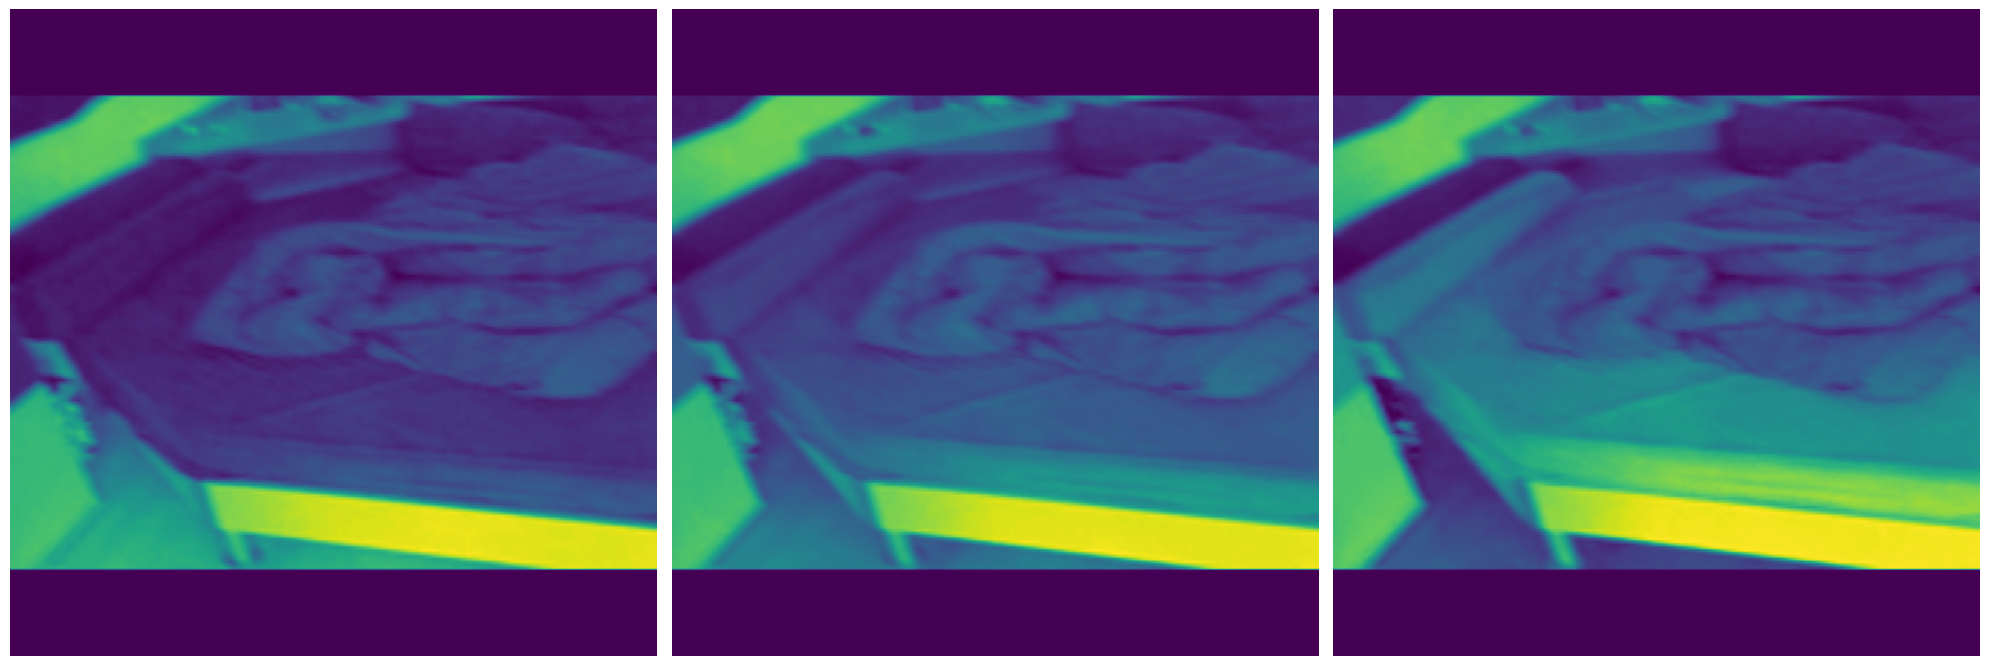

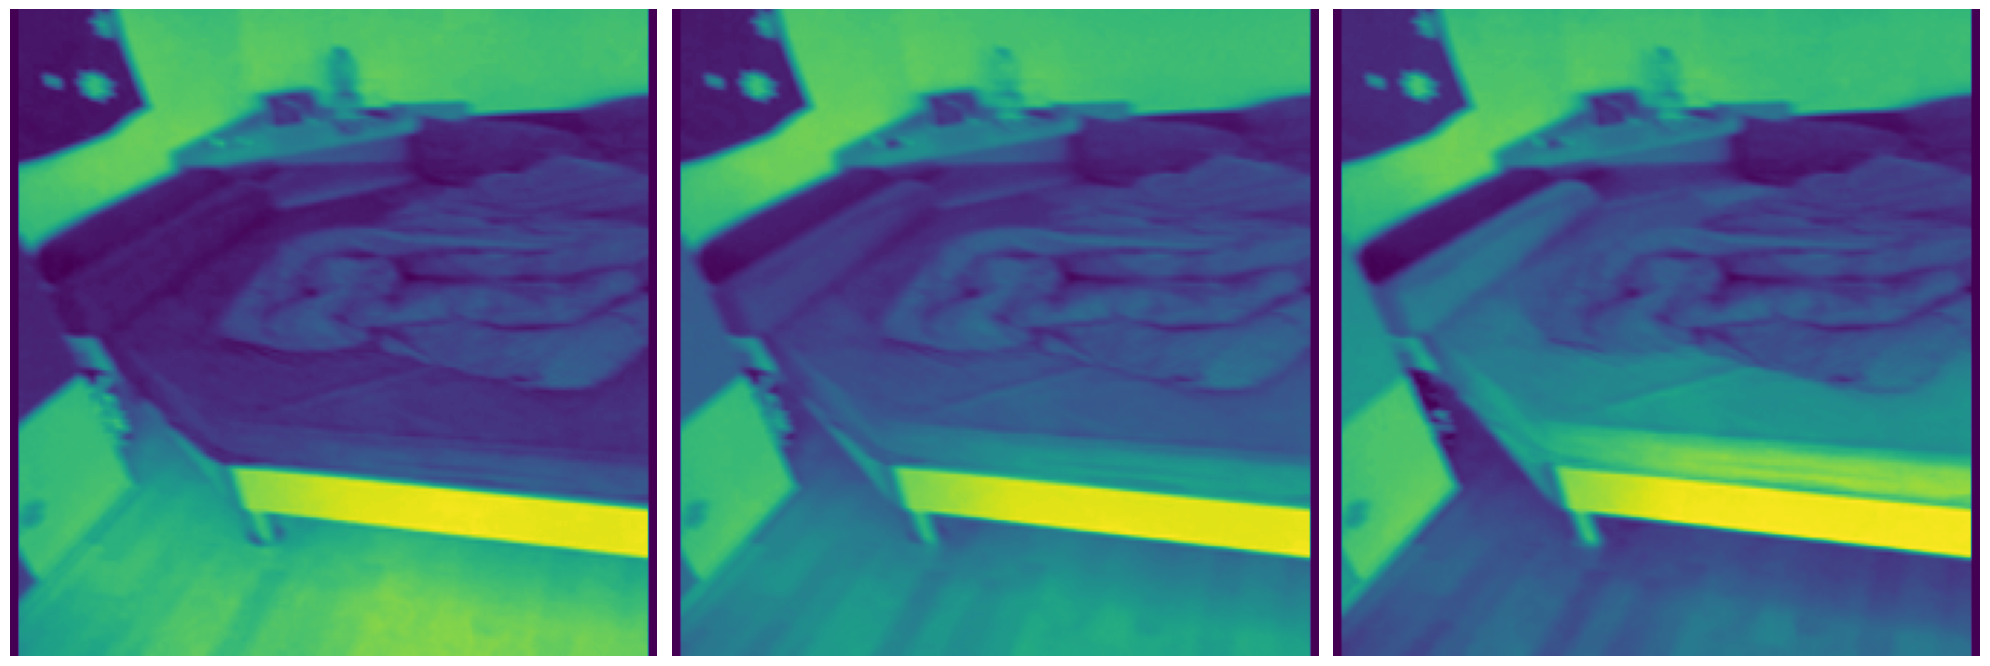

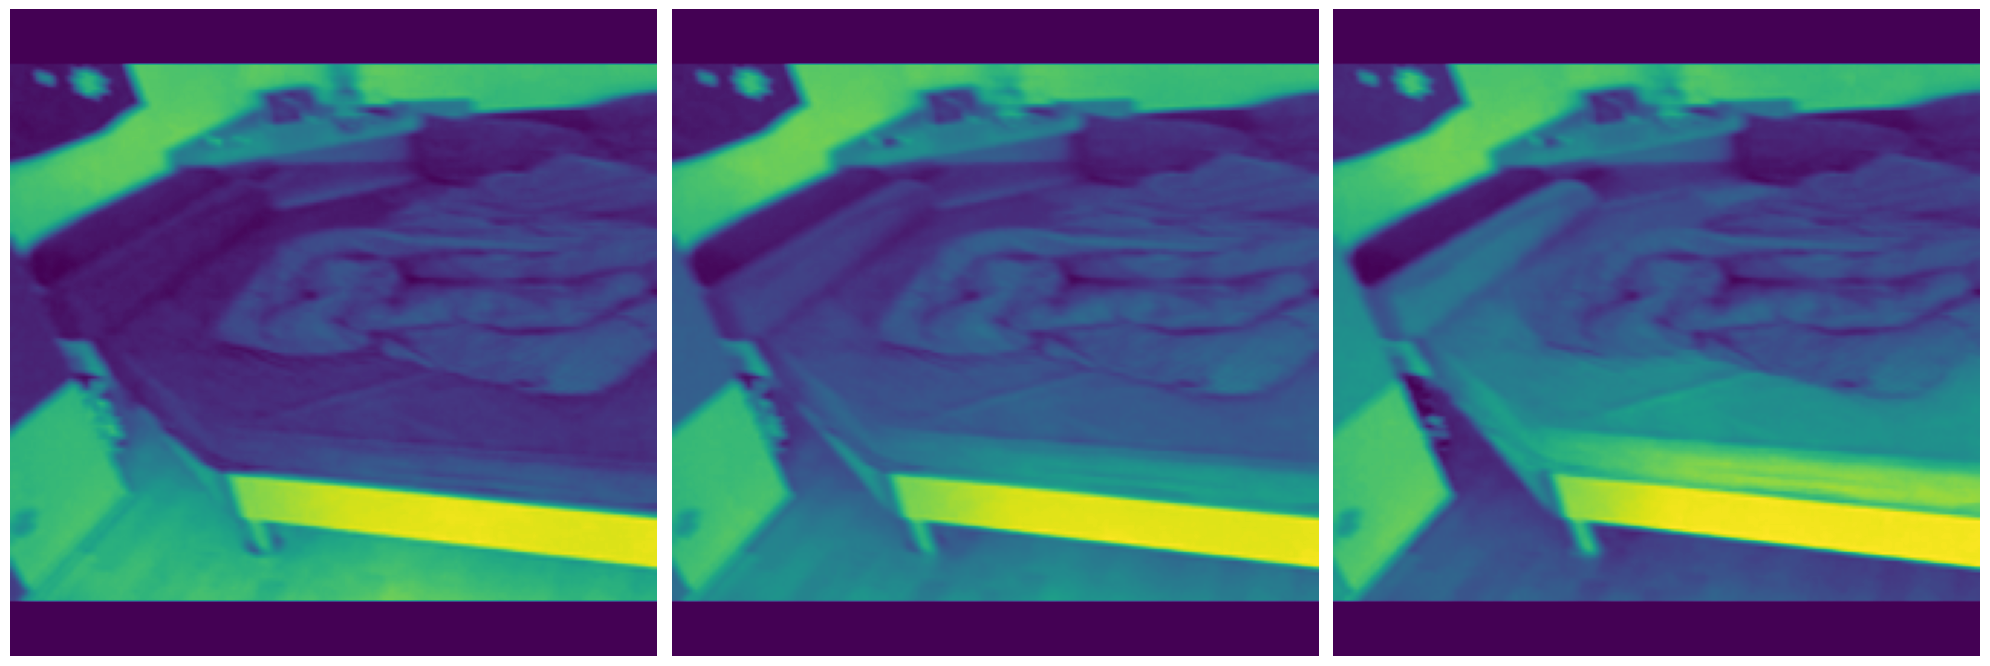

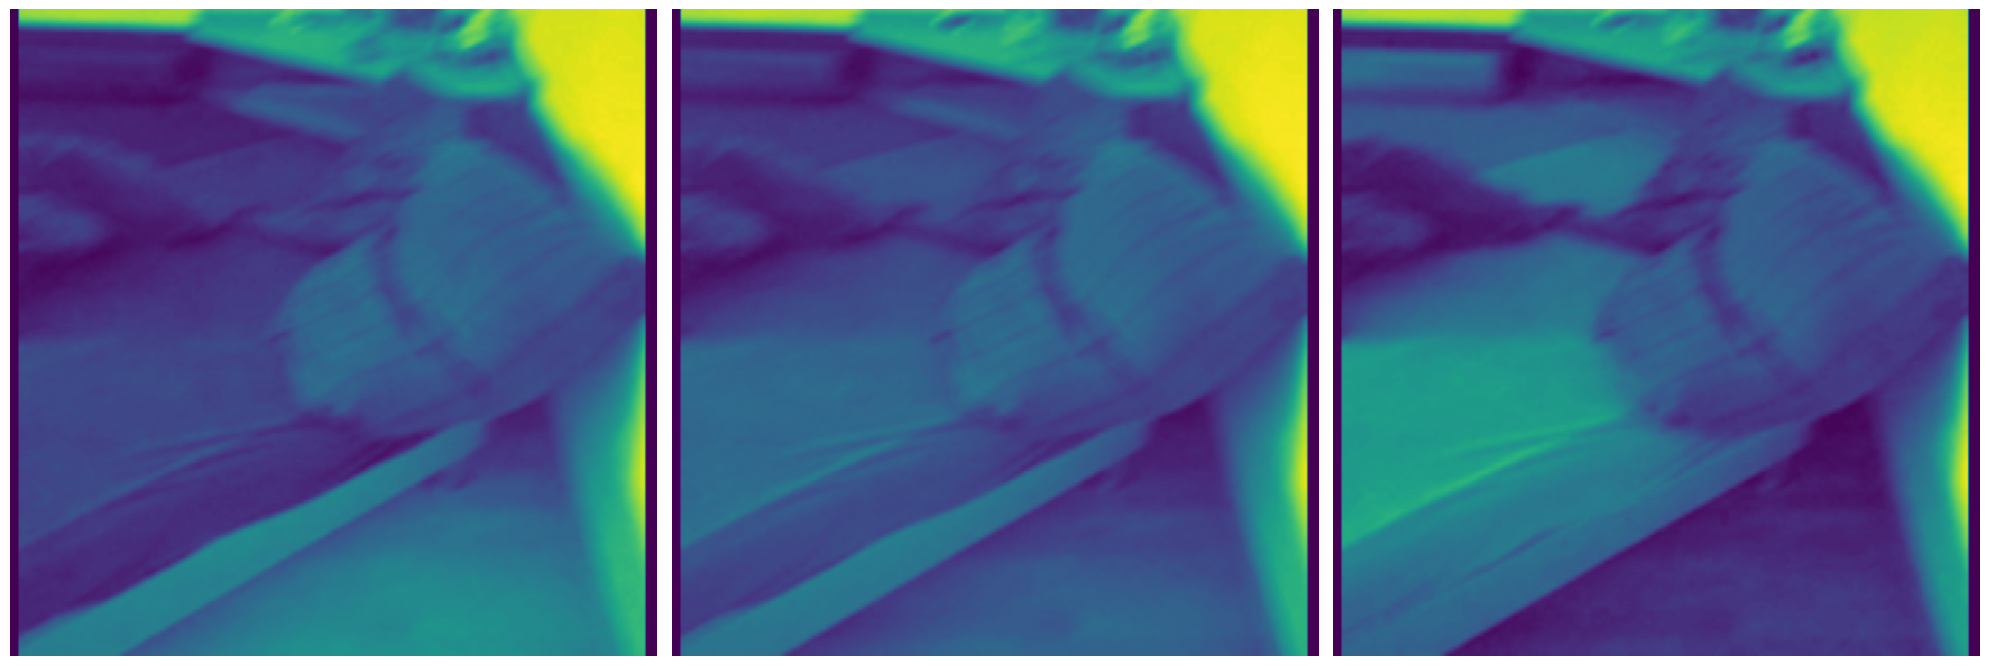

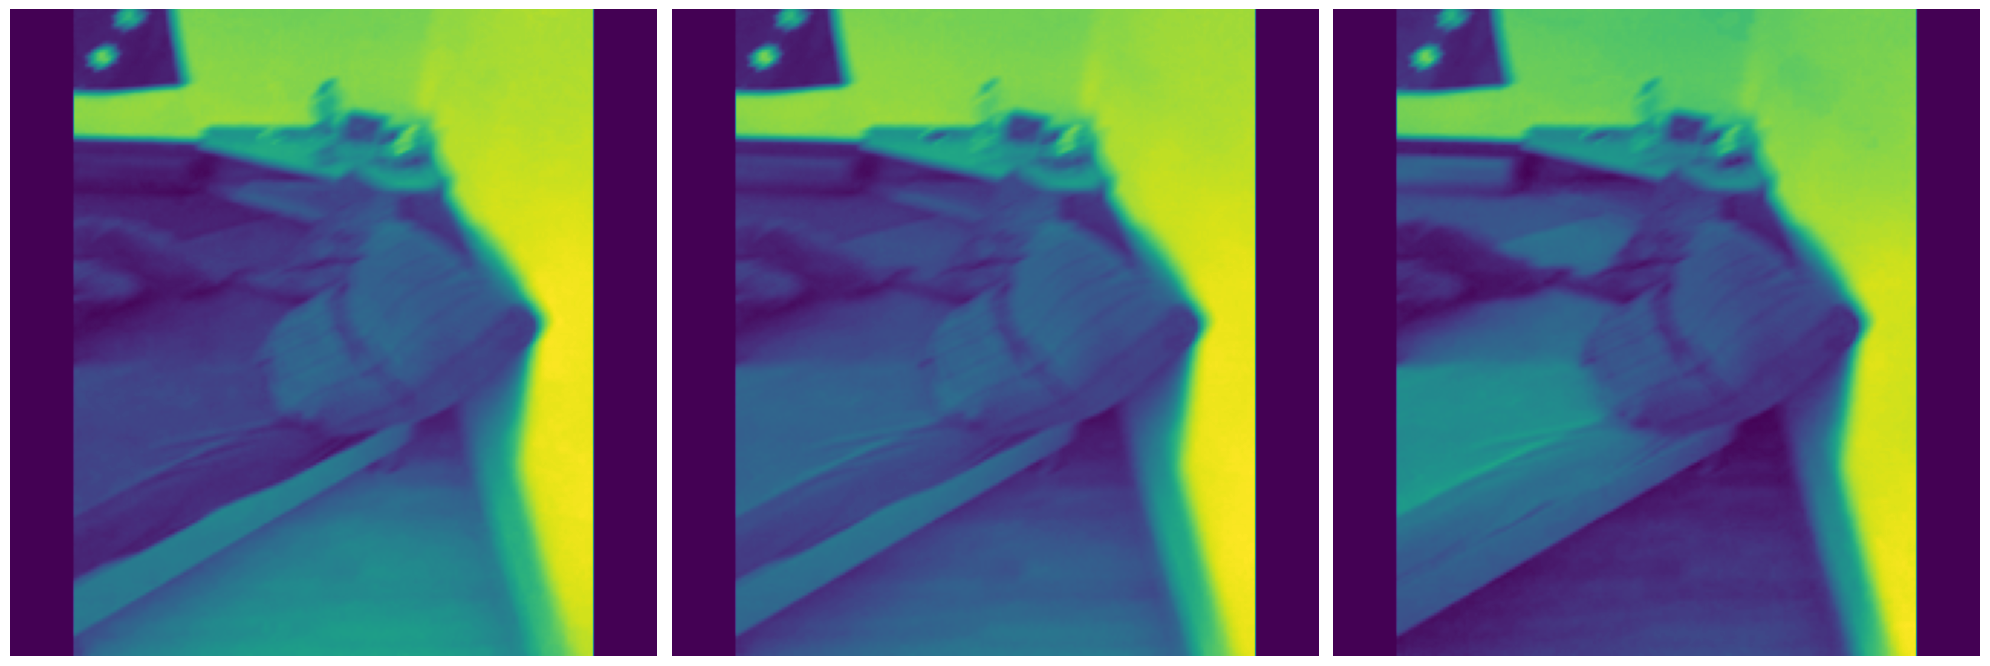

In [31]:
rel_images = data_dict['object_imgs'][0]
print('Number of ... ', len(rel_images))
for idx, image_set in enumerate(rel_images[:5]):
    fig, axes = plt.subplots(1, len(image_set), figsize=(20, 10))  # Adjust figsize as needed
    if len(image_set) == 1:
        axes = [axes]
    for ax, image in zip(axes, image_set):
        ax.imshow(image)
        ax.axis('off')  

    plt.tight_layout()
    plt.show()

### Creating relationship queries

In [32]:
obj_class_dict = [line.rstrip() for line in open(os.path.join(CONF_PATH_R3SCAN_RAW, "classes.txt"), "r").readlines()]
bidx = 7
obj_count = data_dict['objects_count'].item()
rel_count = int(data_dict["predicate_count"].item())
objects_gt = data_dict['objects_cat']
edges = data_dict['edges'][:rel_count]
object_edges = np.array(objects_gt[:obj_count][edges], dtype=np.int32)
object_edges = np.array(obj_class_dict)[object_edges]
object_edges[object_edges == 'socket'] = 'wall'
queries = [
f"Describe the relationship between the {o[0]} and the {'other ' if o[0]==o[1] else ''}{o[1]}. Start the response with: the {o[0]}" if o[0] != o[1]
else f"Describe the relationship between the {o[0]} and the {'other ' if o[0]==o[1] else ''}{o[1]}. Start the response with: the {o[0]}"
for o in object_edges]
print(queries[1])
object_edges

Describe the relationship between the object and the wardrobe. Start the response with: the object


array([['wardrobe', 'floor'],
       ['object', 'wardrobe'],
       ['wall', 'floor'],
       ['bed', 'floor'],
       ['blanket', 'bed'],
       ['pillow', 'bed'],
       ['wardrobe', 'bed'],
       ['bed', 'wardrobe'],
       ['blanket', 'pillow'],
       ['pillow', 'blanket'],
       ['bed', 'blanket'],
       ['bed', 'pillow'],
       ['bed', 'object'],
       ['bed', 'wall'],
       ['blanket', 'floor'],
       ['blanket', 'wardrobe'],
       ['blanket', 'object'],
       ['blanket', 'wall'],
       ['pillow', 'floor'],
       ['pillow', 'wardrobe'],
       ['pillow', 'object'],
       ['pillow', 'wall'],
       ['floor', 'bed'],
       ['floor', 'blanket'],
       ['floor', 'pillow'],
       ['floor', 'wardrobe'],
       ['floor', 'object'],
       ['floor', 'wall'],
       ['wardrobe', 'blanket'],
       ['wardrobe', 'pillow'],
       ['wardrobe', 'object'],
       ['wardrobe', 'wall'],
       ['object', 'bed'],
       ['object', 'blanket'],
       ['object', 'pillow'],
       [

### Combine for LLava3D Input
\+ Poses
\+ Intrinsics

Describe the relationship between the wardrobe and the floor. Start the response with: the wardrobe


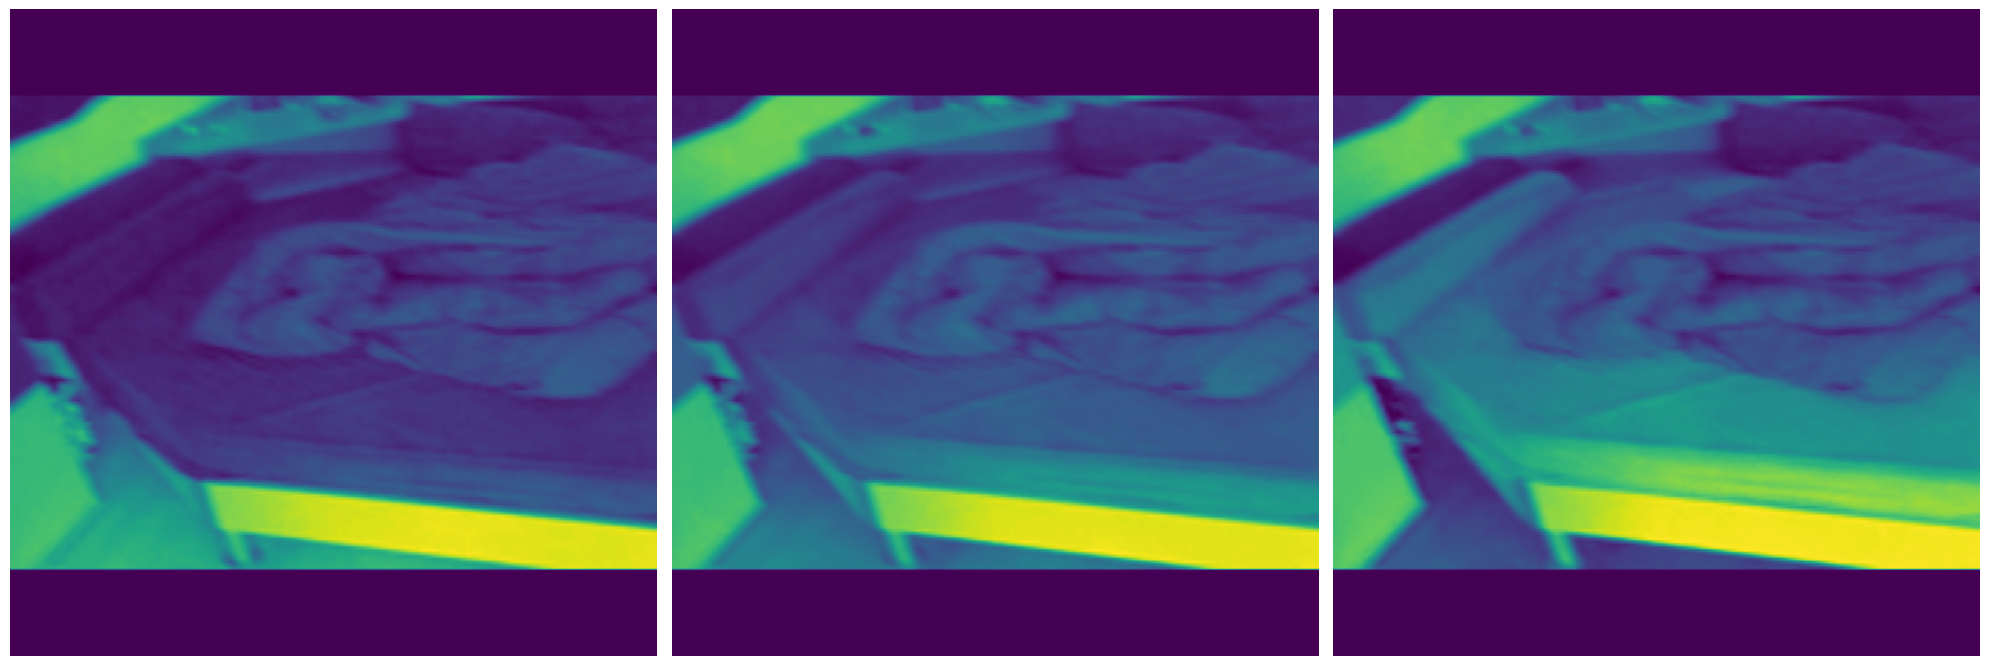

Describe the relationship between the object and the wardrobe. Start the response with: the object


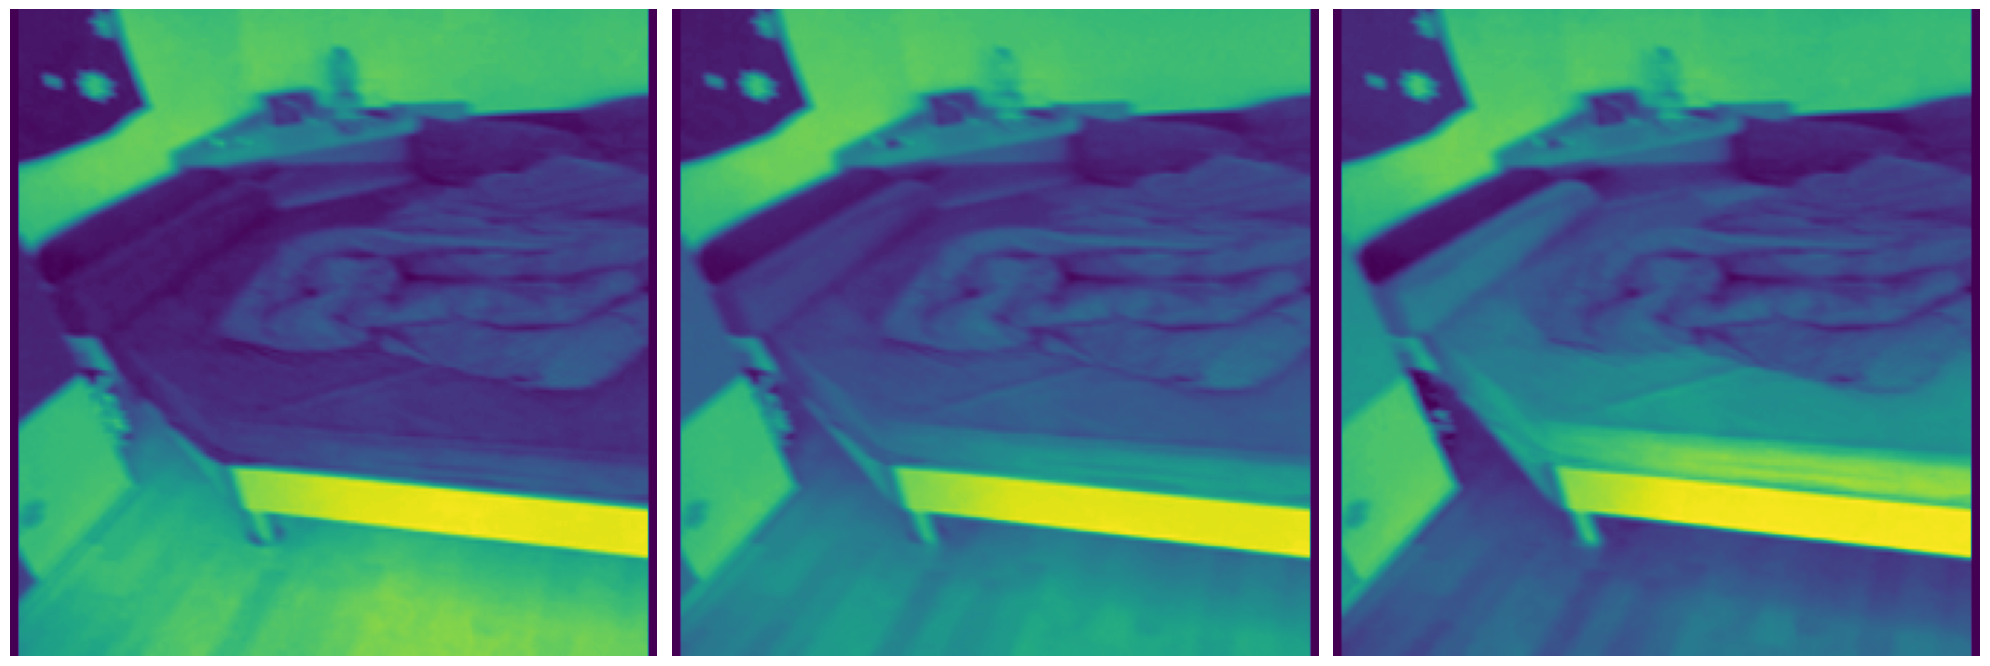

Describe the relationship between the wall and the floor. Start the response with: the wall


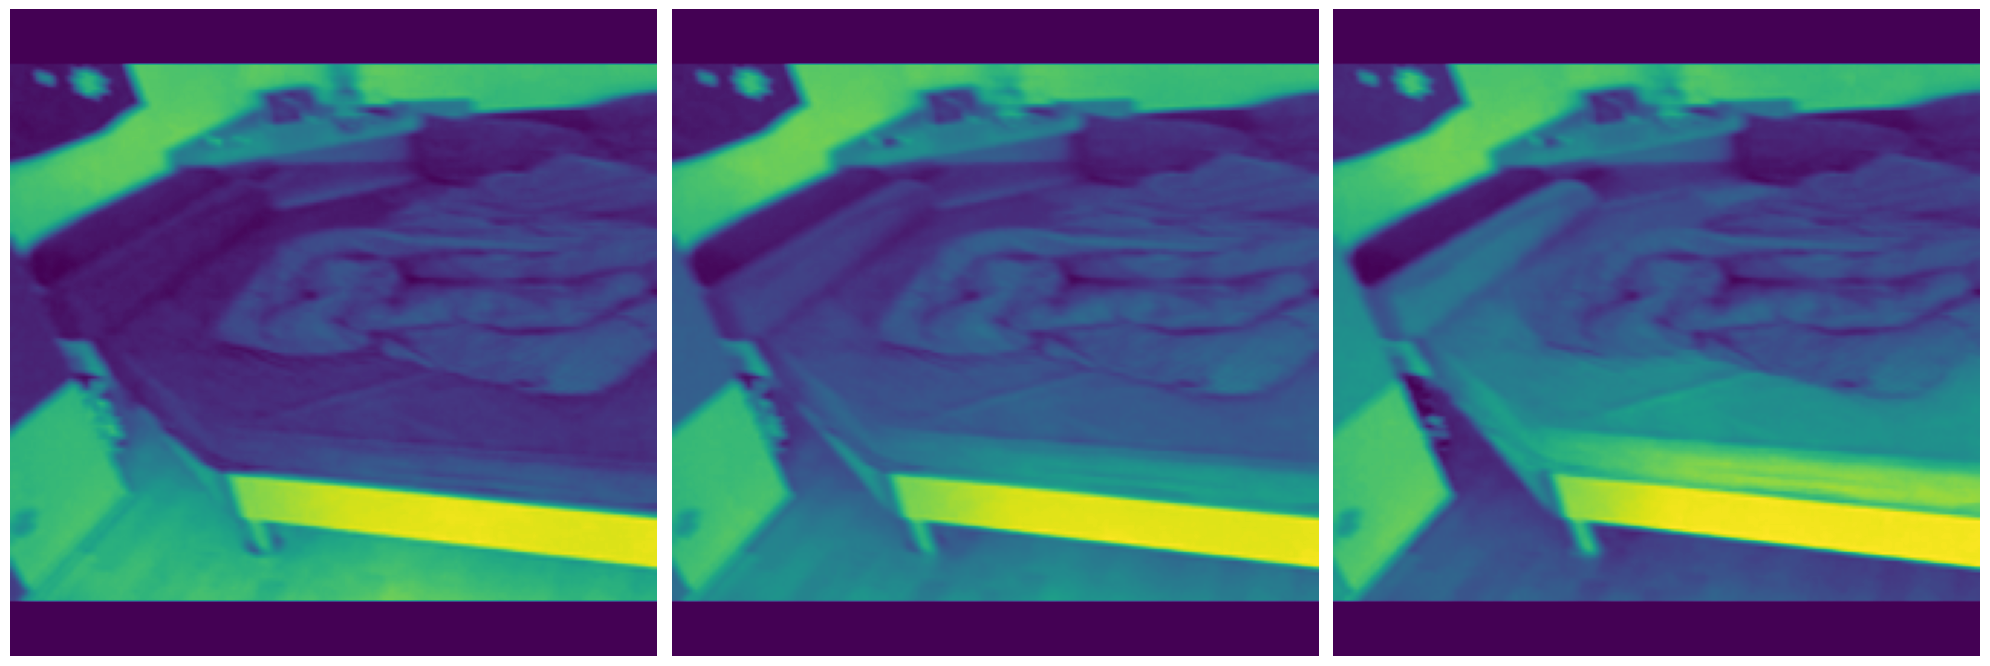

Describe the relationship between the bed and the floor. Start the response with: the bed


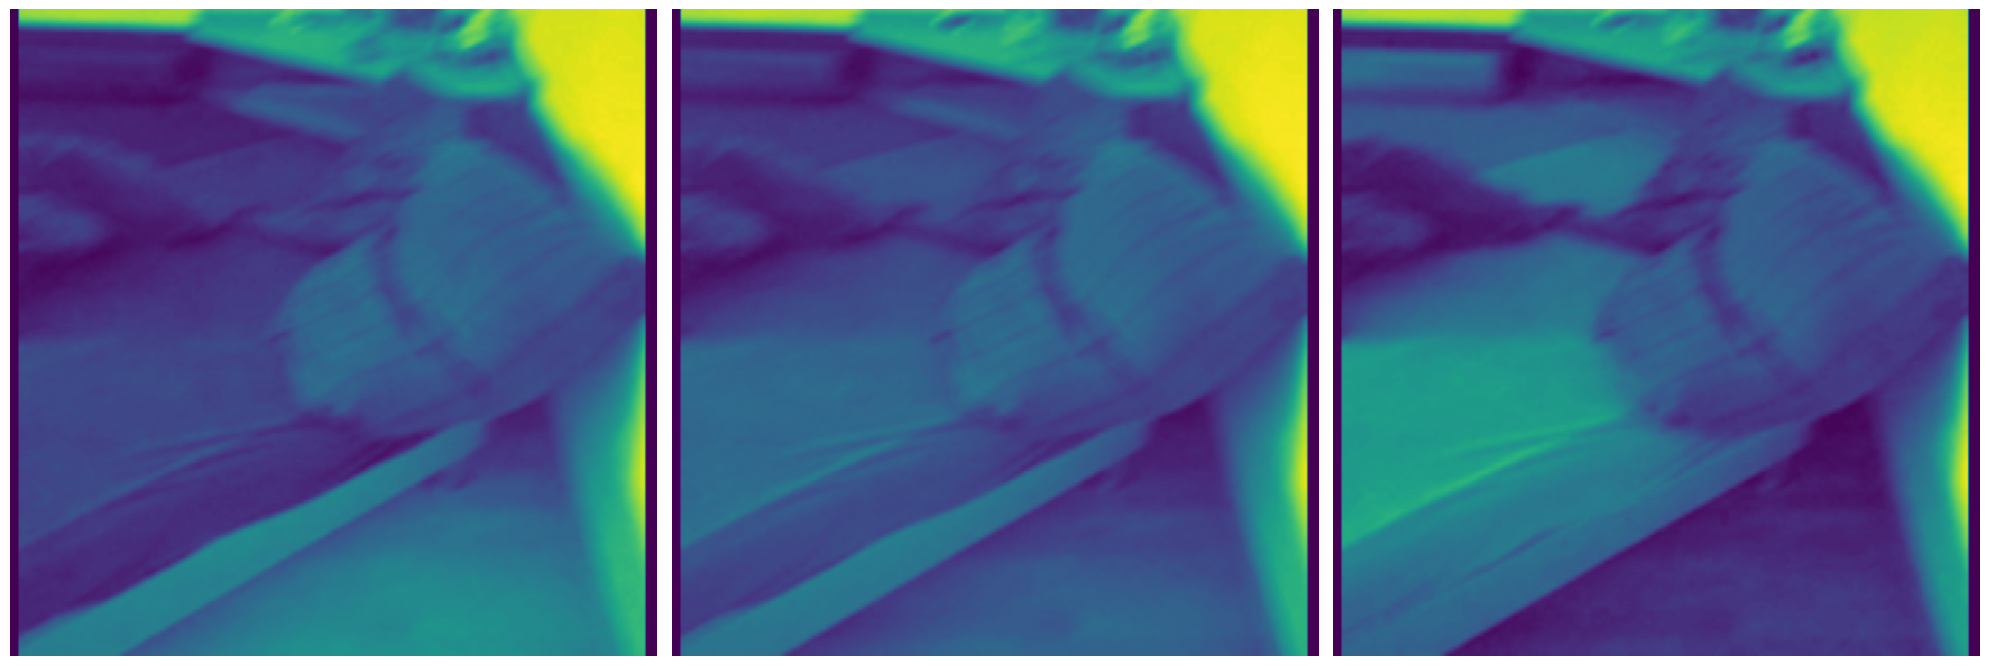

Describe the relationship between the blanket and the bed. Start the response with: the blanket


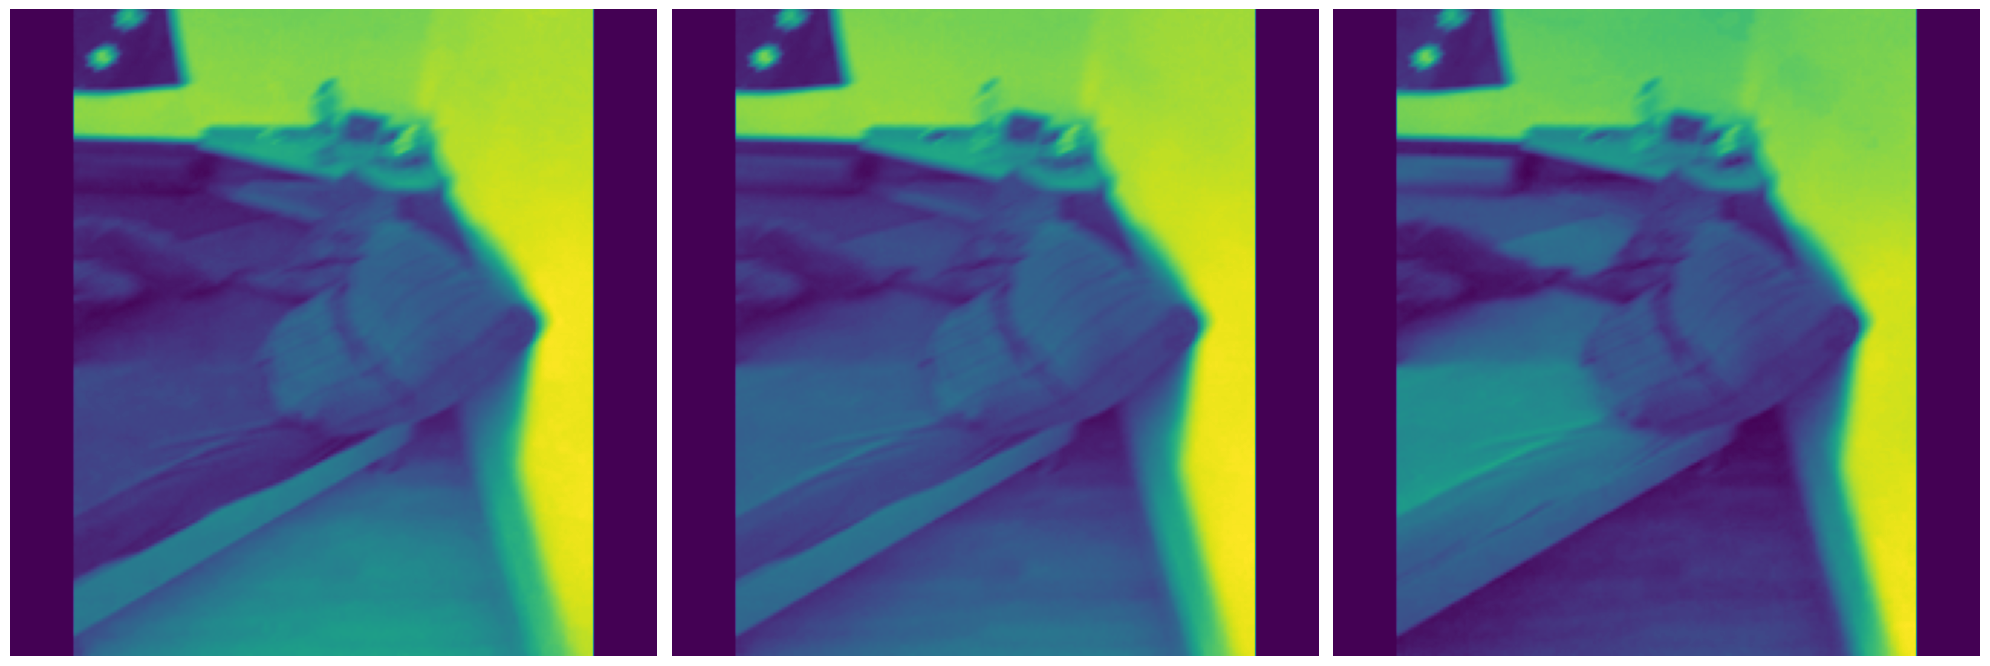

In [33]:
for idx, image_set in enumerate(rel_images[:5]):
    fig, axes = plt.subplots(1, len(image_set), figsize=(20, 10))  # Adjust figsize as needed

    if len(image_set) == 1:
        axes = [axes]

    for ax, image in zip(axes, image_set):
        ax.imshow(image)
        ax.axis('off')  
    print(queries[idx])
    plt.tight_layout()
    plt.show()